In [2]:
import numpy as np
import pandas as pd

In [3]:
df= pd.read_csv("Target.csv")
pd.set_option('display.max_columns', None)
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 5:20:57 PM GMT+5:30,24,Others,Once a month,Clothing and Fashion;others,No,Rarely,Keyword,First page,1,Maybe,Rarely,others,Often,No,Heavily,Yes,4,Sometimes,2,1,Customer service,I don't have any problem with Amazon,567877
1,2023/06/12 2:44:47 PM GMT+5:30,12,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,categories,First page,5,No,Rarely,Changed my mind or no longer need the item,Often,Yes,Occasionally,Yes,4,Sometimes,5,3,Competitive prices,Nil,313221
2,2023/06/09 2:39:16 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion;Home and Kitchen,No,Multiple times a day,Keyword,Multiple pages,2,No,Always,others,Sometimes,Yes,Rarely,Sometimes,2,Yes,3,2,.,I have no problem with Amazon yet. But others ...,532959
3,2023/06/08 7:33:15 AM GMT+5:30,51,Female,Multiple times a week,Beauty and Personal Care;Clothing and Fashion;...,No,Multiple times a day,categories,First page,1,Yes,Sometimes,Found a better price elsewhere,Often,No,Never,Sometimes,4,Sometimes,1,4,Product recommendations,Irrelevant product suggestions,310717
4,2023/06/11 11:01:04 PM GMT+5:30,46,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Keyword,First page,4,Yes,Often,Found a better price elsewhere,Rarely,No,Rarely,Yes,3,No,2,5,Product recommendations,Add more familiar brands to the list,661323


In [4]:
df.shape

(800, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   620 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

In [6]:
# Task 1
df = df.drop_duplicates()

In [7]:
df.isnull().sum()

Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     180
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction                       0
Service_Appreciation              

In [8]:
df['Product_Search_Method'].value_counts(dropna=False)

Product_Search_Method
NaN           180
Keyword       173
others        158
Filter        157
categories    132
Name: count, dtype: int64

In [9]:
mode_value = df['Product_Search_Method'].mode()[0]
df['Product_Search_Method'].fillna(mode_value, inplace=True)

C:\Users\anant\AppData\Local\Temp\ipykernel_7000\2061856681.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product_Search_Method'].fillna(mode_value, inplace=True)


In [10]:
df.columns = df.columns.str.strip()

In [11]:
cols = ['Customer_Reviews_Importance', 'Shopping_Satisfaction']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [12]:
# Task 2

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

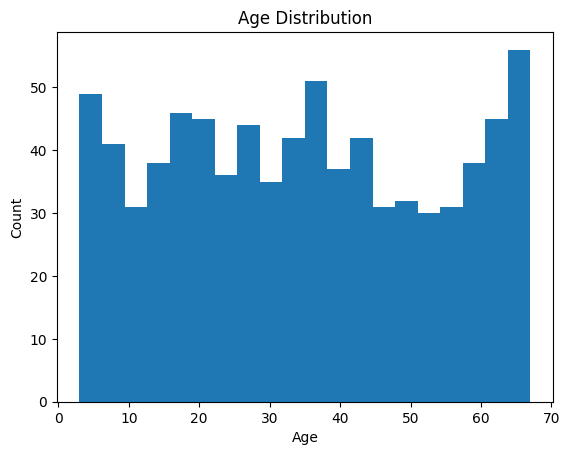

In [14]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

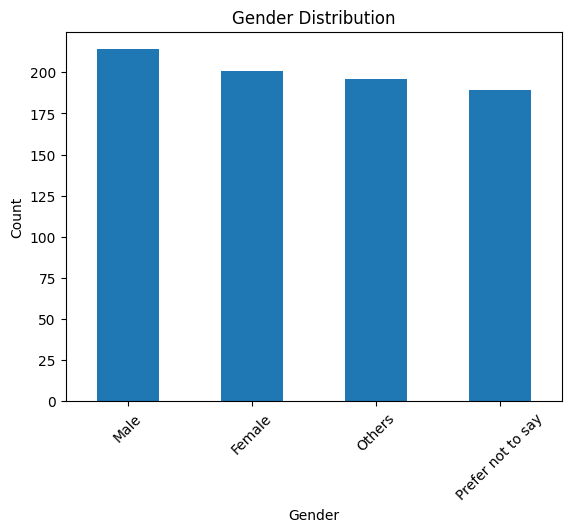

In [15]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

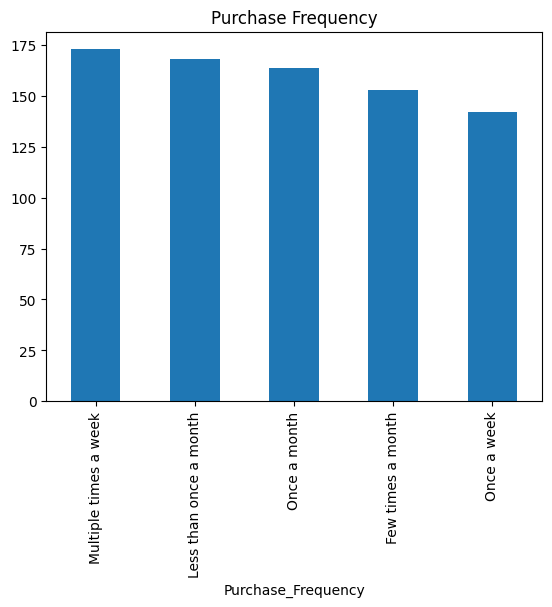

In [16]:
df['Purchase_Frequency'].value_counts().plot(kind='bar')
plt.title("Purchase Frequency")
plt.show()

In [17]:
most_purchased = df['Purchase_Categories'].value_counts().idxmax()
print("Most Purchased Category:", most_purchased)

Most Purchased Category: Groceries and Gourmet Food;Beauty and Personal Care;others


In [18]:
top_browsing = df['Product_Search_Method'].value_counts().idxmax()
print("Top Browsing Method:", top_browsing)

Top Browsing Method: Keyword


In [19]:
common_cart = df['Cart_Abandonment_Factors'].value_counts().idxmax()
print("Top Cart Abandonment Factor:", common_cart)

Top Cart Abandonment Factor: High shipping costs


In [20]:
df['Recommendation_Helpfulness'].unique()

array(['Sometimes', 'Yes', 'No'], dtype=object)

In [21]:
df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].str.strip().str.capitalize()

In [22]:
mapping = {'No': 1, 'Sometimes': 2, 'Yes': 3}
df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].map(mapping)

In [23]:
df['Recommendation_Helpfulness'].isnull().sum()

np.int64(0)

In [24]:
print("Shopping Satisfaction Mean:", df['Shopping_Satisfaction'].mean())
print("Shopping Satisfaction Median:", df['Shopping_Satisfaction'].median())

print("Recommendation Helpfulness Mean:", df['Recommendation_Helpfulness'].mean())
print("Recommendation Helpfulness Median:", df['Recommendation_Helpfulness'].median())

print("Rating Accuracy Mean:", df['Rating_Accuracy'].mean())
print("Rating Accuracy Median:", df['Rating_Accuracy'].median())

Shopping Satisfaction Mean: 2.935
Shopping Satisfaction Median: 3.0
Recommendation Helpfulness Mean: 2.0
Recommendation Helpfulness Median: 2.0
Rating Accuracy Mean: 3.05875
Rating Accuracy Median: 3.0


In [25]:
df[['Shopping_Satisfaction', 
    'Recommendation_Helpfulness', 
    'Rating_Accuracy']].describe()

,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
count,800.000000,800.00000,800.000000
mean,2.935000,2.00000,3.058750
std,1.436438,0.81445,1.439753
min,1.000000,1.00000,1.000000
25%,2.000000,1.00000,2.000000
50%,3.000000,2.00000,3.000000
75%,4.000000,3.00000,4.000000
max,5.000000,3.00000,5.000000


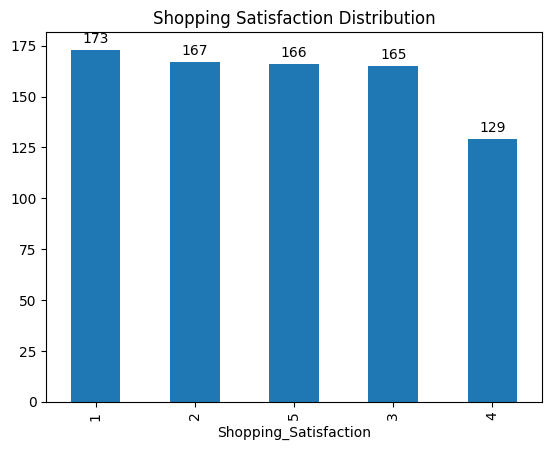

In [26]:
ax=df['Shopping_Satisfaction'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.title("Shopping Satisfaction Distribution")
plt.show()

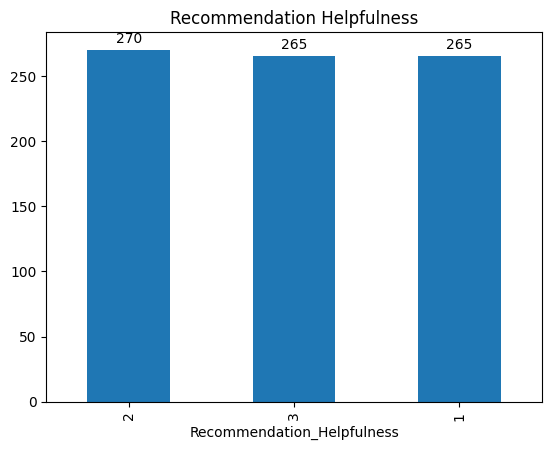

In [27]:
ax=df['Recommendation_Helpfulness'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.title("Recommendation Helpfulness")
plt.show()

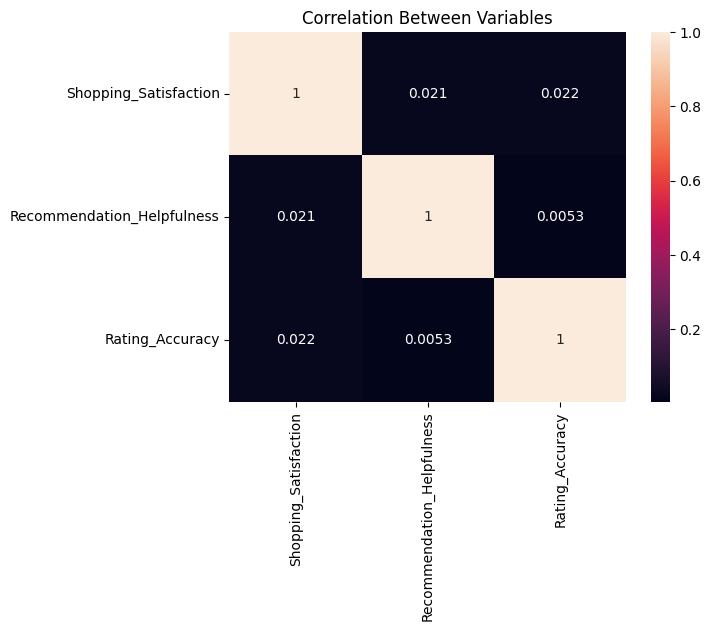

In [28]:
corr = df[['Shopping_Satisfaction', 
           'Recommendation_Helpfulness', 
           'Rating_Accuracy']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Between Variables")
plt.show()

In [29]:
# Task 3
df["Purchase_Frequency"].unique()

array(['Once a month', 'Multiple times a week', 'Few times a month',
       'Less than once a month', 'Once a week'], dtype=object)

In [30]:
df['Purchase_Frequency'] = df['Purchase_Frequency'].str.strip().str.lower()

In [31]:
mapping = {'less than once a month': 1,'once a month': 2,'few times a month': 3,'once a week': 4,
           'multiple times a week': 5}
df['Purchase_Frequency'] = df['Purchase_Frequency'].map(mapping)

In [32]:
def segment(row):
    if row['Purchase_Frequency'] >= 4 and row['Shopping_Satisfaction'] >= 4:
        return 'Frequent Buyers' 
    elif row['Purchase_Frequency'] == 3:
        return 'Occasional Shoppers'
    else:
        return 'At-Risk Customers'
df['Segment'] = df.apply(segment, axis=1)

In [33]:
df['Segment'].value_counts()

Segment
At-Risk Customers      535
Occasional Shoppers    153
Frequent Buyers        112
Name: count, dtype: int64

In [34]:
df.groupby('Segment')[['Purchase_Frequency', 'Shopping_Satisfaction']].mean()

,Purchase_Frequency,Shopping_Satisfaction
Segment,,
At-Risk Customers,2.656075,2.614953
Frequent Buyers,4.535714,4.544643
Occasional Shoppers,3.000000,2.875817


In [35]:
X = df[['Purchase_Frequency',
        'Shopping_Satisfaction',]]

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 10):   # start from 2 (1 cluster not valid)
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score}")

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

k=2, Silhouette Score=0.3594318314465096
k=3, Silhouette Score=0.398794420813351
k=4, Silhouette Score=0.4403572634295457
k=5, Silhouette Score=0.4359957766923865
k=6, Silhouette Score=0.4212526009088796
k=7, Silhouette Score=0.4344651819576944
k=8, Silhouette Score=0.447036977468172
k=9, Silhouette Score=0.49256812323992294


C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [37]:
print(X.dtypes)

Purchase_Frequency       int64
Shopping_Satisfaction    int64
dtype: object


C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

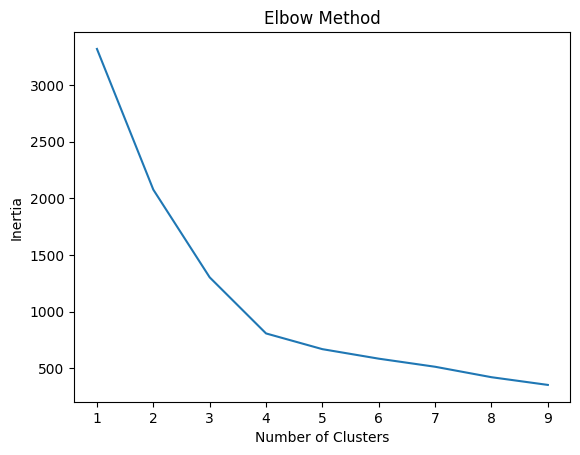

In [38]:
from sklearn.cluster import KMeans
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.plot(K, inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [39]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
pred4= kmeans.predict(X)
print(pred4)

[1 2 0 2 2 1 0 2 2 2 1 0 1 2 3 2 2 2 2 0 3 2 3 3 0 2 3 3 3 1 1 2 2 3 2 1 2
 0 1 0 3 1 3 0 2 3 2 0 3 3 1 0 0 1 2 1 1 0 2 3 3 1 2 0 2 3 0 1 1 1 0 0 3 2
 2 1 2 0 2 0 3 0 0 3 3 0 0 3 2 2 1 1 2 2 2 0 0 2 1 0 2 3 1 0 2 3 1 1 2 1 3
 1 2 3 1 3 0 3 2 1 0 1 3 2 0 0 1 0 0 3 1 1 0 1 1 1 2 3 0 2 0 1 2 0 2 3 3 1
 3 3 1 2 0 0 3 0 0 3 1 1 0 3 3 0 2 0 1 1 1 2 3 2 0 1 0 1 0 0 0 3 0 0 2 1 1
 0 1 1 2 0 0 2 3 0 1 3 3 2 1 0 3 3 0 2 1 0 1 0 0 1 1 1 0 2 2 1 3 0 1 2 0 2
 0 2 1 2 2 2 2 1 0 0 3 0 3 0 2 0 2 1 0 2 1 3 1 1 3 0 1 1 1 0 1 2 0 1 3 0 3
 0 3 1 2 2 3 3 1 0 0 3 0 0 0 2 0 2 1 2 1 2 0 1 1 1 1 0 1 0 3 0 1 3 2 3 1 0
 2 2 2 0 1 1 3 1 0 1 0 3 2 2 2 2 2 0 2 2 2 3 3 1 1 2 2 2 1 0 0 0 1 1 3 2 2
 2 3 1 2 2 0 0 2 0 0 2 1 1 0 3 3 0 1 3 3 3 1 3 1 3 3 0 3 3 0 3 0 2 1 0 2 2
 1 2 0 2 2 0 1 2 1 3 0 3 2 0 2 3 1 0 2 0 2 1 2 0 1 2 2 2 0 2 0 3 0 2 3 0 1
 1 2 0 3 0 2 1 0 1 2 1 2 2 0 1 1 1 2 1 1 0 1 0 0 2 1 1 1 1 3 1 2 2 0 1 2 2
 3 1 0 3 3 1 2 0 1 3 3 3 1 0 3 1 0 3 3 2 1 2 1 2 2 3 3 2 3 1 1 3 0 0 2 3 0
 1 0 0 1 2 1 1 1 3 2 1 2 

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [40]:
from collections import Counter
c1= Counter(pred4)
print(c1)

Counter({np.int32(1): 236, np.int32(2): 209, np.int32(0): 202, np.int32(3): 153})


In [41]:
cent4 = kmeans.cluster_centers_
print(cent4)

[[4.04455446 1.46039604]
 [1.68220339 2.1440678 ]
 [4.32535885 3.97129187]
 [1.76470588 4.68627451]]


In [42]:
df['Cls4']= pred4
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Segment,Cls4
0,2023/06/08 5:20:57 PM GMT+5:30,24,Others,2,Clothing and Fashion;others,No,Rarely,Keyword,First page,1,Maybe,Rarely,others,Often,No,Heavily,Yes,4,2,2,1,Customer service,I don't have any problem with Amazon,567877,At-Risk Customers,1
1,2023/06/12 2:44:47 PM GMT+5:30,12,Male,5,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,categories,First page,5,No,Rarely,Changed my mind or no longer need the item,Often,Yes,Occasionally,Yes,4,2,5,3,Competitive prices,Nil,313221,At-Risk Customers,2
2,2023/06/09 2:39:16 PM GMT+5:30,14,Prefer not to say,3,Clothing and Fashion;Home and Kitchen,No,Multiple times a day,Keyword,Multiple pages,2,No,Always,others,Sometimes,Yes,Rarely,Sometimes,2,3,3,2,.,I have no problem with Amazon yet. But others ...,532959,Occasional Shoppers,0
3,2023/06/08 7:33:15 AM GMT+5:30,51,Female,5,Beauty and Personal Care;Clothing and Fashion;...,No,Multiple times a day,categories,First page,1,Yes,Sometimes,Found a better price elsewhere,Often,No,Never,Sometimes,4,2,1,4,Product recommendations,Irrelevant product suggestions,310717,Frequent Buyers,2
4,2023/06/11 11:01:04 PM GMT+5:30,46,Male,5,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Keyword,First page,4,Yes,Often,Found a better price elsewhere,Rarely,No,Rarely,Yes,3,1,2,5,Product recommendations,Add more familiar brands to the list,661323,Frequent Buyers,2


In [43]:
df.groupby('Cls4')[X.columns].mean()

,Purchase_Frequency,Shopping_Satisfaction
Cls4,,
0,4.044554,1.460396
1,1.682203,2.144068
2,4.325359,3.971292
3,1.764706,4.686275


In [44]:
# Task 4
df[['Recommendation_Helpfulness', 'Shopping_Satisfaction']].corr()

,Recommendation_Helpfulness,Shopping_Satisfaction
Recommendation_Helpfulness,1.000000,0.021396
Shopping_Satisfaction,0.021396,1.000000


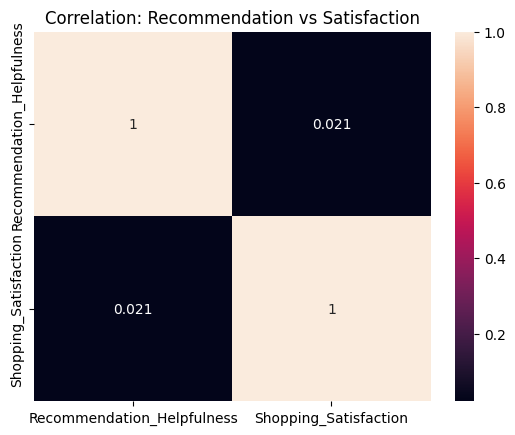

In [45]:
plt.figure()
sns.heatmap(df[['Recommendation_Helpfulness', 'Shopping_Satisfaction']].corr(),annot=True)
plt.title("Correlation: Recommendation vs Satisfaction")
plt.show()

In [46]:
df['Review_Reliability'].unique()

array(['Heavily', 'Occasionally', 'Rarely', 'Never', 'Moderately'],
      dtype=object)

In [47]:
df['Review_Reliability'] = df['Review_Reliability'].astype(str)
df['Review_Reliability'] = df['Review_Reliability'].str.strip().str.capitalize()

In [48]:
mapping = {'Never': 1,'Rarely': 2,'Occasionally': 3,'Moderately': 4,'Heavily': 5}
df['Review_Reliability'] = df['Review_Reliability'].map(mapping)

In [49]:
df['Review_Helpfulness'].unique()

array(['Yes', 'Sometimes', 'No'], dtype=object)

In [50]:
df['Review_Helpfulness'] = df['Review_Helpfulness'].astype(str)
df['Review_Helpfulness'] = df['Review_Helpfulness'].str.strip().str.capitalize()

In [51]:
mapping = {'No': 1,'Sometimes': 2,'Yes': 3}
df['Review_Helpfulness'] = df['Review_Helpfulness'].map(mapping)

In [52]:
df[['Review_Reliability', 'Review_Helpfulness', 'Rating_Accuracy']].corr()


,Review_Reliability,Review_Helpfulness,Rating_Accuracy
Review_Reliability,1.000000,-0.056668,-0.020609
Review_Helpfulness,-0.056668,1.000000,-0.024622
Rating_Accuracy,-0.020609,-0.024622,1.000000


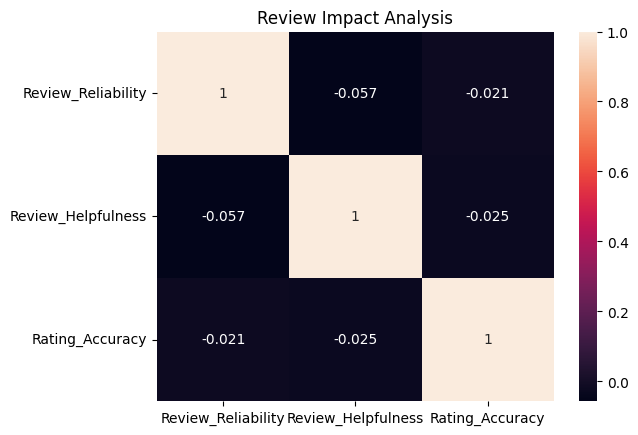

In [53]:
plt.figure()
sns.heatmap(df[['Review_Reliability', 'Review_Helpfulness', 'Rating_Accuracy']].corr(),annot=True)
plt.title("Review Impact Analysis")
plt.show()

In [54]:
cols = list(df.columns)
cols[17] = 'Personalized_Recommendation_Frequency_Num'
df.columns = cols

In [55]:
df['Personalized_Recommendation_Frequency_Num'].value_counts

<bound method IndexOpsMixin.value_counts of 0      4
1      4
2      2
3      4
4      3
      ..
795    3
796    3
797    3
798    4
799    5
Name: Personalized_Recommendation_Frequency_Num, Length: 800, dtype: int64>

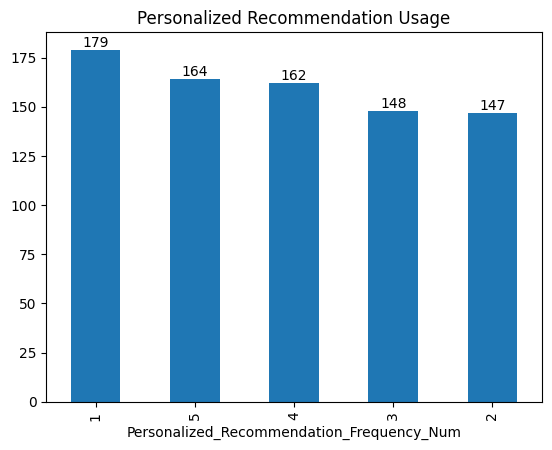

In [56]:
ax = df['Personalized_Recommendation_Frequency_Num'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title("Personalized Recommendation Usage")
plt.show()

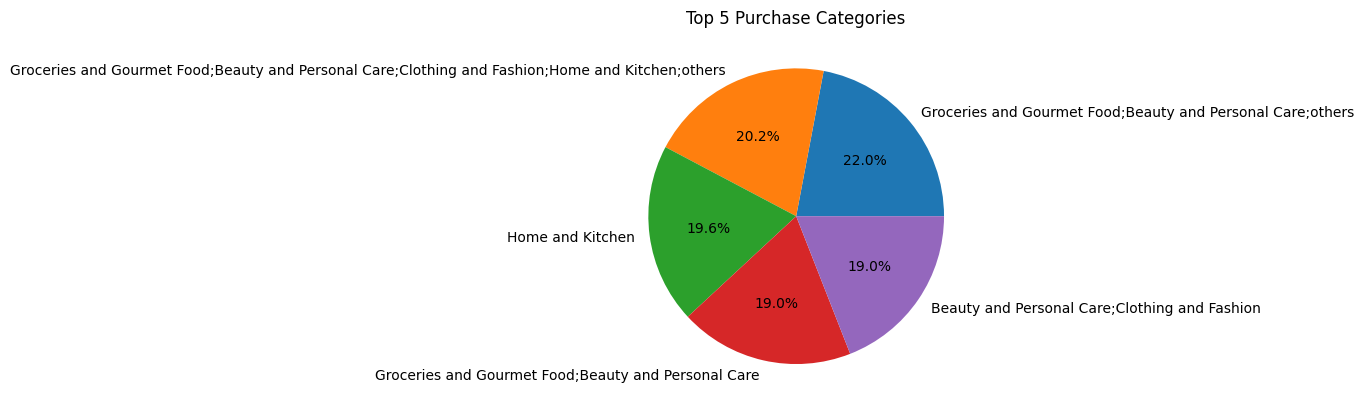

In [57]:
# Task 5 
top_categories = df['Purchase_Categories'].value_counts().head(5)
plt.figure()
top_categories.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Purchase Categories")
plt.ylabel('')
plt.show()

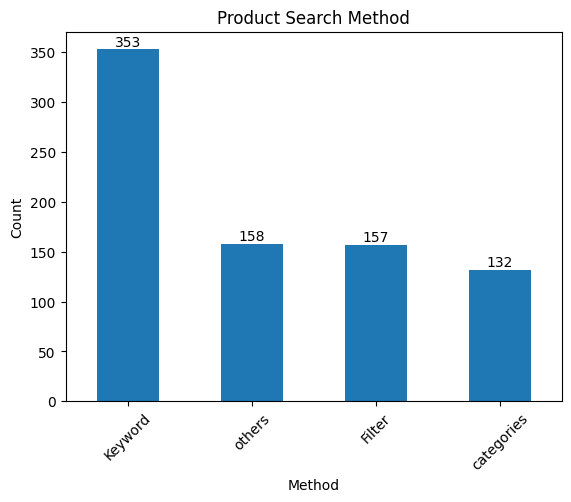

In [63]:
plt.figure()
ax = df['Product_Search_Method'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title("Product Search Method")
plt.xlabel("Method") 
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

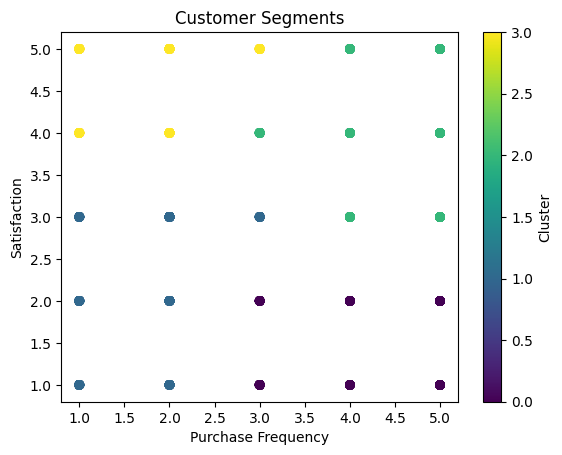

In [59]:
plt.figure()
scatter = plt.scatter(df['Purchase_Frequency'],
                      df['Shopping_Satisfaction'],
                      c=df['Cls4'])
plt.colorbar(scatter, label='Cluster')
plt.xlabel("Purchase Frequency")
plt.ylabel("Satisfaction")
plt.title("Customer Segments")
plt.show()

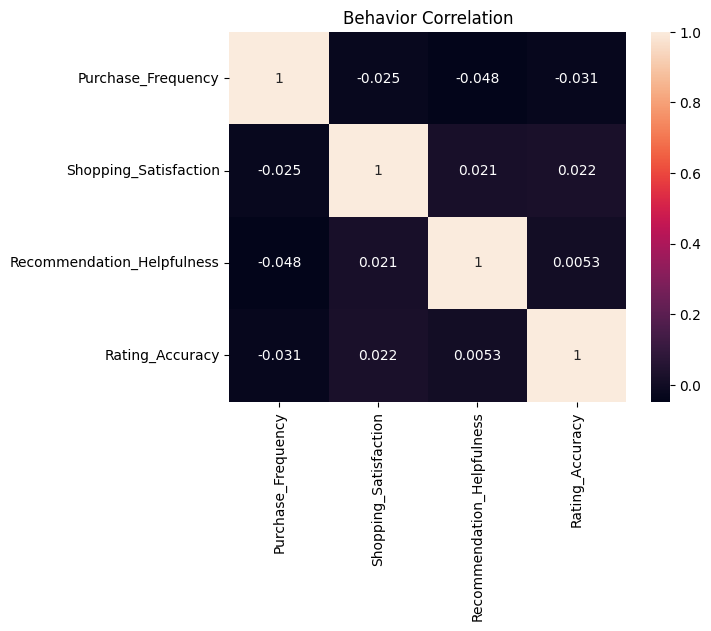

In [60]:
plt.figure()
sns.heatmap(df[['Purchase_Frequency',
                'Shopping_Satisfaction',
                'Recommendation_Helpfulness',
                'Rating_Accuracy']].corr(),
            annot=True)
plt.title("Behavior Correlation")
plt.show()